#  Network Traffic Time Series & Forecasting Project


##  Data Cleaning & Preparation

In [3]:
pip install pandas==2.2.2 numpy==1.26.4

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
# --- Imports ---
try:
    import pandas as pd
    import numpy as np
except ModuleNotFoundError:
    print("❌ Pandas/Numpy not installed in this environment")
    import sys
    print("👉 Python being used:", sys.executable)
    exit()

# --- File path (ABSOLUTE PATH) ---
file_path = r"C:\Users\HP\OneDrive\Documents\GitHub\Time Series Analysis Project\network_traffic.csv"

# --- Load dataset ---
try:
    df = pd.read_csv(file_path)
    print("✅ File loaded successfully")
except FileNotFoundError:
    print("❌ File not found. Check the path.")
    exit()

# --- Convert time column ---
df['time'] = pd.to_datetime(df['time'], errors='coerce')

# --- Drop invalid timestamps ---
df = df.dropna(subset=['time'])

# --- Create total traffic ---
df['total_bytes'] = df['bytes_sent'].fillna(0) + df['bytes_received'].fillna(0)

# --- Set index ---
df = df.set_index('time').sort_index()

# --- Resample hourly ---
df_hourly = df['total_bytes'].resample('H').sum()

# --- Fill missing values ---
df_hourly = df_hourly.ffill()

# --- Output ---
print(df_hourly.head())

✅ File loaded successfully
time
2025-04-06 20:00:00    42286156
2025-04-06 21:00:00    48600212
2025-04-06 22:00:00    58224022
2025-04-06 23:00:00    51184084
2025-04-07 00:00:00    48728215
Freq: h, Name: total_bytes, dtype: int64


C:\Users\HP\AppData\Local\Temp\ipykernel_27752\1581374906.py:35: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_hourly = df['total_bytes'].resample('H').sum()


In [5]:
import pandas as pd

df = pd.read_csv("network_traffic.csv")
df['time'] = pd.to_datetime(df['time'])
df['total_bytes'] = df['bytes_sent'] + df['bytes_received']
df = df.set_index('time').sort_index()

df_hourly = df['total_bytes'].resample('H').sum()
df_hourly = df_hourly.fillna(method='ffill')

df_hourly.head()

C:\Users\HP\AppData\Local\Temp\ipykernel_27752\2141807860.py:8: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_hourly = df['total_bytes'].resample('H').sum()
C:\Users\HP\AppData\Local\Temp\ipykernel_27752\2141807860.py:9: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_hourly = df_hourly.fillna(method='ffill')


time
2025-04-06 20:00:00    42286156
2025-04-06 21:00:00    48600212
2025-04-06 22:00:00    58224022
2025-04-06 23:00:00    51184084
2025-04-07 00:00:00    48728215
Freq: h, Name: total_bytes, dtype: int64

In [1]:
!pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable


In [7]:
import sys
!{sys.executable} -m pip install matplotlib

     ---------------------------------------- 0.0/52.8 kB ? eta -:--:--
     -------------- ----------------------- 20.5/52.8 kB 330.3 kB/s eta 0:00:01
     ---------------------- --------------- 30.7/52.8 kB 262.6 kB/s eta 0:00:01
     ----------------------------- -------- 41.0/52.8 kB 281.8 kB/s eta 0:00:01
     -------------------------------------- 52.8/52.8 kB 247.6 kB/s eta 0:00:00
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
     ---------------------------------------- 0.0/119.8 kB ? eta -:--:--
     -------------------- ------------------- 61.4/119.8 kB ? eta -:--:--
     -------------------- ------------------- 61.4/119.8 kB ? eta -:--:--
     -------------------- ------------------- 61.4/119.8 kB ? eta -:--:--
     -------------------- ------------------- 61.4/119.8 kB ? eta -:--:--
     -------------------- ------------------- 61.4/119.8 kB ? eta -:--:--
     -------------------- ------------------- 61.4/119.8 kB ? eta -:--:--
     ----------------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


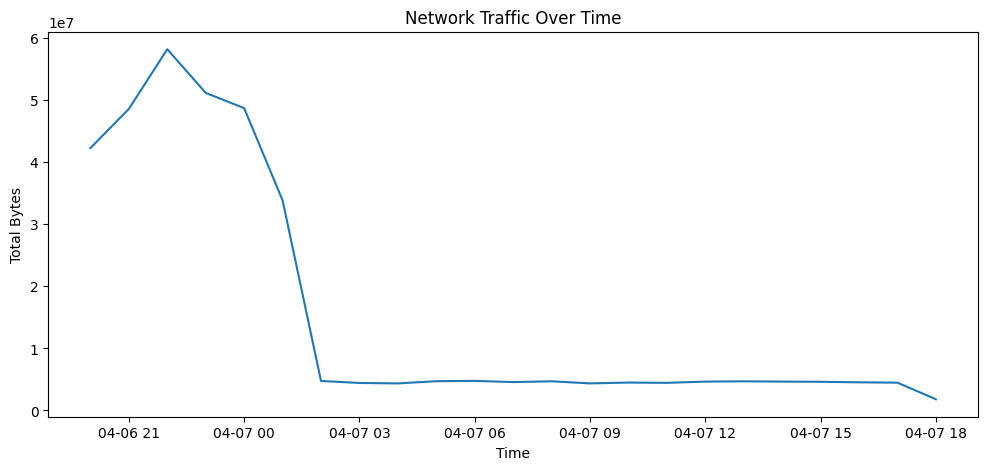

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(df_hourly)
plt.title("Network Traffic Over Time")
plt.xlabel("Time")
plt.ylabel("Total Bytes")
plt.show()

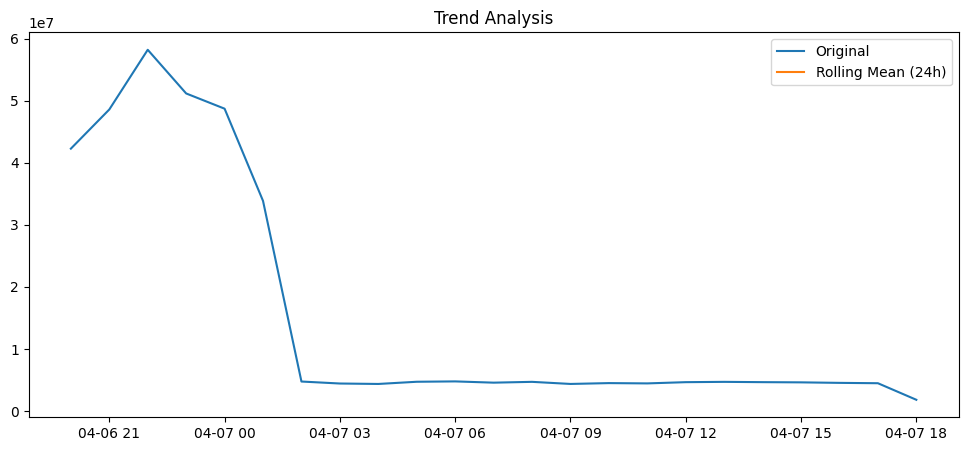

In [9]:
rolling = df_hourly.rolling(window=24).mean()

plt.figure(figsize=(12,5))
plt.plot(df_hourly, label='Original')
plt.plot(rolling, label='Rolling Mean (24h)')
plt.legend()
plt.title("Trend Analysis")
plt.show()

In [11]:
import sys
!{sys.executable} -m pip install statsmodels

     ---------------------------------------- 0.0/61.0 kB ? eta -:--:--
     ------ --------------------------------- 10.2/61.0 kB ? eta -:--:--
     ------ --------------------------------- 10.2/61.0 kB ? eta -:--:--
     ------------------- ------------------ 30.7/61.0 kB 330.3 kB/s eta 0:00:01
     ------------------------- ------------ 41.0/61.0 kB 245.8 kB/s eta 0:00:01
     -------------------------------------- 61.0/61.0 kB 294.8 kB/s eta 0:00:00
  Using cached patsy-1.0.2-py2.py3-none-any.whl.metadata (3.6 kB)
   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ---------------------------------------- 0.1/9.6 MB 2.0 MB/s eta 0:00:05
   ---------------------------------------- 0.1/9.6 MB 1.7 MB/s eta 0:00:06
   ---------------------------------------- 0.1/9.6 MB 1.7 MB/s eta 0:00:06
    --------------------------------------- 0.2/9.6 MB 930.9 kB/s eta 0:00:11
    --------------------------------------- 0.2/9.6 MB 1.1 MB/s eta 0:00:09
    ---------------------


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [12]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(df_hourly, order=(1,1,1))
model_fit = model.fit()

forecast = model_fit.forecast(steps=24)
forecast

2025-04-07 19:00:00    1.178294e+06
2025-04-07 20:00:00    9.295927e+05
2025-04-07 21:00:00    8.315465e+05
2025-04-07 22:00:00    7.928936e+05
2025-04-07 23:00:00    7.776553e+05
2025-04-08 00:00:00    7.716479e+05
2025-04-08 01:00:00    7.692796e+05
2025-04-08 02:00:00    7.683459e+05
2025-04-08 03:00:00    7.679778e+05
2025-04-08 04:00:00    7.678327e+05
2025-04-08 05:00:00    7.677755e+05
2025-04-08 06:00:00    7.677530e+05
2025-04-08 07:00:00    7.677441e+05
2025-04-08 08:00:00    7.677406e+05
2025-04-08 09:00:00    7.677392e+05
2025-04-08 10:00:00    7.677386e+05
2025-04-08 11:00:00    7.677384e+05
2025-04-08 12:00:00    7.677383e+05
2025-04-08 13:00:00    7.677383e+05
2025-04-08 14:00:00    7.677383e+05
2025-04-08 15:00:00    7.677383e+05
2025-04-08 16:00:00    7.677383e+05
2025-04-08 17:00:00    7.677383e+05
2025-04-08 18:00:00    7.677383e+05
Freq: h, Name: predicted_mean, dtype: float64

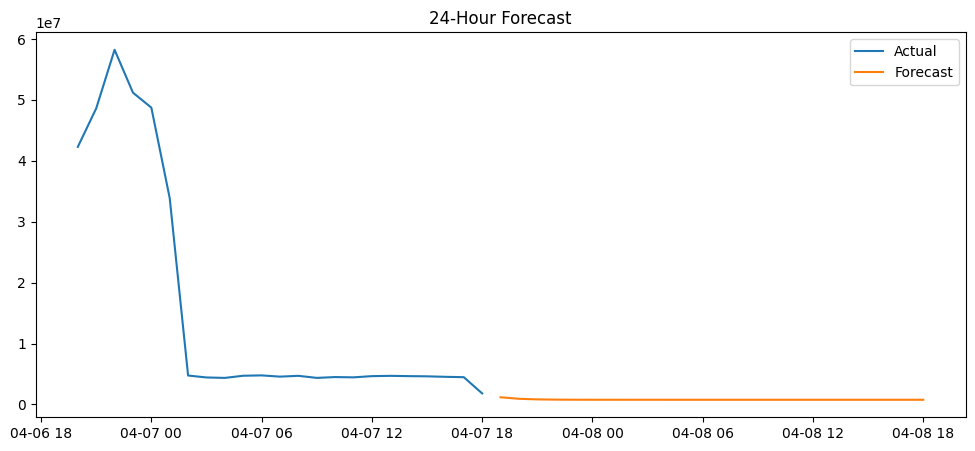

In [13]:
plt.figure(figsize=(12,5))
plt.plot(df_hourly[-100:], label='Actual')
plt.plot(forecast, label='Forecast')
plt.legend()
plt.title("24-Hour Forecast")
plt.show()

In [14]:
import sys
!{sys.executable} -m pip install streamlit

  Using cached streamlit-1.55.0-py3-none-any.whl.metadata (9.8 kB)
  Using cached altair-6.0.0-py3-none-any.whl.metadata (11 kB)
  Using cached blinker-1.9.0-py3-none-any.whl.metadata (1.6 kB)
  Using cached cachetools-7.0.5-py3-none-any.whl.metadata (5.6 kB)
  Using cached click-8.3.1-py3-none-any.whl.metadata (2.6 kB)
  Using cached gitpython-3.1.46-py3-none-any.whl.metadata (13 kB)
  Using cached pydeck-0.9.1-py2.py3-none-any.whl.metadata (4.1 kB)
  Using cached protobuf-6.33.6-cp310-abi3-win_amd64.whl.metadata (593 bytes)
  Using cached tenacity-9.1.4-py3-none-any.whl.metadata (1.2 kB)
  Using cached toml-0.10.2-py2.py3-none-any.whl.metadata (7.1 kB)
  Using cached watchdog-6.0.0-py3-none-win_amd64.whl.metadata (44 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached jsonschema-4.26.0-py3-none-any.whl.metadata (7.6 kB)
  Using cached narwhals-2.18.1-py3-none-any.whl.metadata (14 kB)
  Using cached gitdb-4.0.12-py3-none-any.whl.metadata (1.2 kB)
     ---

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


SyntaxError: invalid syntax (3357972877.py, line 1)